# Exploratory Data Analysis (EDA) - Retail Sales Dataset

## Project Overview
This notebook performs comprehensive exploratory data analysis on the cleaned retail sales dataset. We'll analyze sales patterns, customer behavior, product performance, and transaction distributions to uncover key insights.

**Objective**: Understand data patterns, customer segments, and business trends through visualization and statistical analysis.

## Step 1: Import Libraries

Import essential libraries for data analysis and visualization.

In [2]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style and options
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## Step 2: Load Cleaned Dataset

Load the preprocessed data from the previous step.

In [3]:
# Load the cleaned dataset
df = pd.read_csv('dataset/retail_sales_dataset.csv')

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Display dataset info
print(f"✓ Dataset loaded successfully!")
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nFirst few rows:")
print(df.head())

✓ Dataset loaded successfully!
Dataset shape: 1000 rows × 9 columns

Column names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

First few rows:
   Transaction ID       Date Customer ID  Gender  Age Product Category  \
0               1 2023-11-24     CUST001    Male   34           Beauty   
1               2 2023-02-27     CUST002  Female   26         Clothing   
2               3 2023-01-13     CUST003    Male   50      Electronics   
3               4 2023-05-21     CUST004    Male   37         Clothing   
4               5 2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


---

# SECTION A: SALES ANALYSIS

## A1. Total Revenue

Calculate the overall revenue generated from all transactions.

In [4]:
# Calculate total revenue
total_revenue = df['Total Amount'].sum()
num_transactions = len(df)
avg_transaction_value = df['Total Amount'].mean()

print("=" * 60)
print("TOTAL REVENUE SUMMARY")
print("=" * 60)
print(f"Total Revenue:           ${total_revenue:,.2f}")
print(f"Number of Transactions:  {num_transactions:,}")
print(f"Average Transaction:     ${avg_transaction_value:,.2f}")
print("=" * 60)

TOTAL REVENUE SUMMARY
Total Revenue:           $456,000.00
Number of Transactions:  1,000
Average Transaction:     $456.00


## A2. Revenue by Product Category

Analyze sales performance across different product categories.

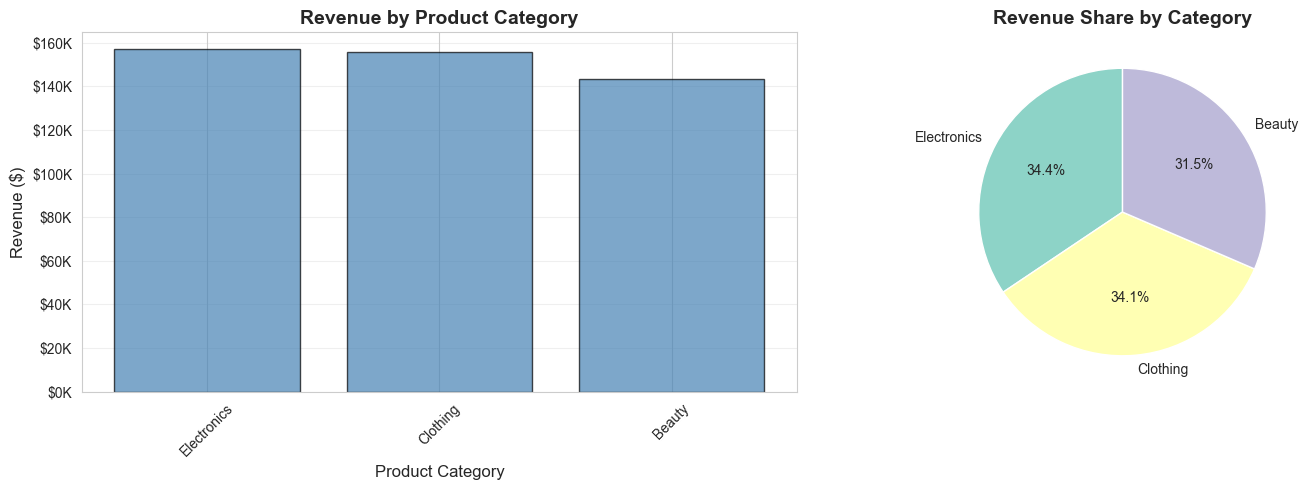


Revenue by Product Category:
Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

Highest Revenue Category: Electronics ($156,905.00)

💡 INSIGHT:
This chart shows which product categories generate the most revenue.
Focus marketing and inventory on top-performing categories for maximum ROI.


In [5]:
# Revenue by Product Category
revenue_by_category = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
axes[0].bar(revenue_by_category.index, revenue_by_category.values, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Revenue by Product Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Product Category', fontsize=12)
axes[0].set_ylabel('Revenue ($)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Format y-axis as currency
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Pie chart
colors = plt.cm.Set3(range(len(revenue_by_category)))
axes[1].pie(revenue_by_category.values, labels=revenue_by_category.index, autopct='%1.1f%%', 
            startangle=90, colors=colors)
axes[1].set_title('Revenue Share by Category', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nRevenue by Product Category:")
print(revenue_by_category)
print(f"\nHighest Revenue Category: {revenue_by_category.idxmax()} (${revenue_by_category.max():,.2f})")

# Insight
print("\n💡 INSIGHT:")
print("This chart shows which product categories generate the most revenue.")
print("Focus marketing and inventory on top-performing categories for maximum ROI.")

## A3. Monthly Sales Trend

Analyze how sales change over time to identify seasonal patterns.

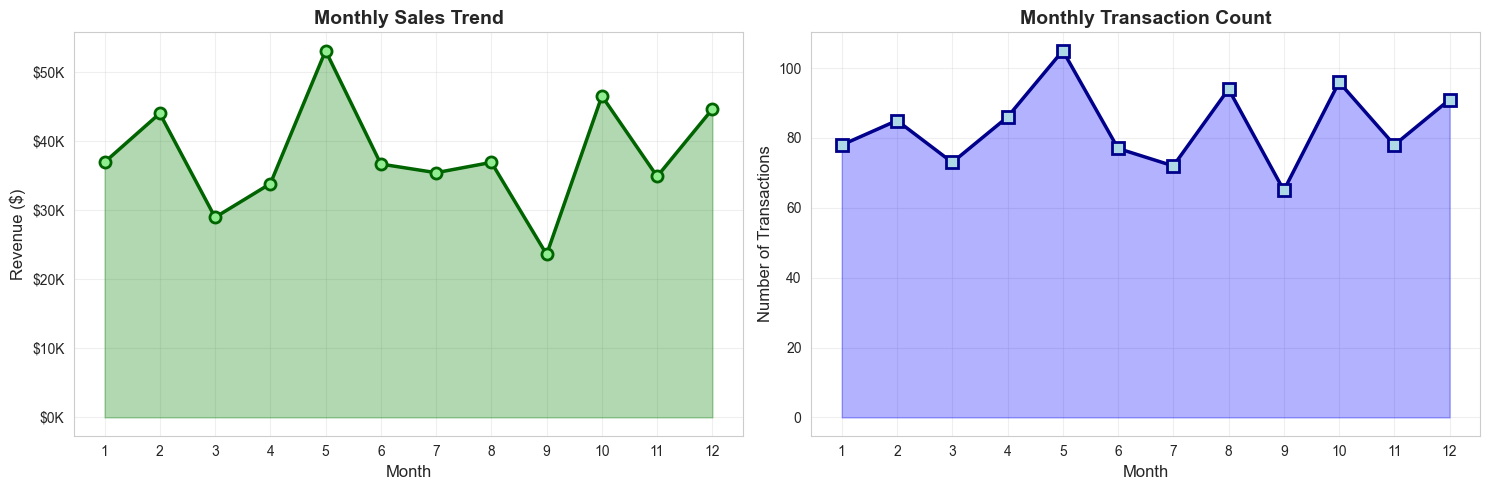


Monthly Sales Summary:
    Month  Total Revenue  Transaction Count  Avg Transaction
0       1          36980                 78       474.102564
1       2          44060                 85       518.352941
2       3          28990                 73       397.123288
3       4          33870                 86       393.837209
4       5          53150                105       506.190476
5       6          36715                 77       476.818182
6       7          35465                 72       492.569444
7       8          36960                 94       393.191489
8       9          23620                 65       363.384615
9      10          46580                 96       485.208333
10     11          34920                 78       447.692308
11     12          44690                 91       491.098901

💡 INSIGHT:
Observe seasonal patterns and identify peak and low sales months.
Use these trends to plan inventory, staffing, and marketing campaigns effectively.


In [6]:
# Check if Month column exists, if not create it
if 'Month' not in df.columns:
    df['Month'] = df['Date'].dt.month

# Monthly sales trend
monthly_sales = df.groupby('Month')['Total Amount'].agg(['sum', 'count', 'mean']).reset_index()
monthly_sales.columns = ['Month', 'Total Revenue', 'Transaction Count', 'Avg Transaction']

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Line chart for revenue
axes[0].plot(monthly_sales['Month'], monthly_sales['Total Revenue'], marker='o', linewidth=2.5, 
             markersize=8, color='darkgreen', markerfacecolor='lightgreen', markeredgewidth=2)
axes[0].fill_between(monthly_sales['Month'], monthly_sales['Total Revenue'], alpha=0.3, color='green')
axes[0].set_title('Monthly Sales Trend', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month', fontsize=12)
axes[0].set_ylabel('Revenue ($)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
axes[0].set_xticks(monthly_sales['Month'])

# Line chart for transaction count
axes[1].plot(monthly_sales['Month'], monthly_sales['Transaction Count'], marker='s', linewidth=2.5, 
             markersize=8, color='darkblue', markerfacecolor='lightblue', markeredgewidth=2)
axes[1].fill_between(monthly_sales['Month'], monthly_sales['Transaction Count'], alpha=0.3, color='blue')
axes[1].set_title('Monthly Transaction Count', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month', fontsize=12)
axes[1].set_ylabel('Number of Transactions', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(monthly_sales['Month'])

plt.tight_layout()
plt.show()

# Print summary
print("\nMonthly Sales Summary:")
print(monthly_sales)

# Insight
print("\n💡 INSIGHT:")
print("Observe seasonal patterns and identify peak and low sales months.")
print("Use these trends to plan inventory, staffing, and marketing campaigns effectively.")

---

# SECTION B: CUSTOMER ANALYSIS

## B1. Age Distribution

Examine the age profile of customers in the dataset.

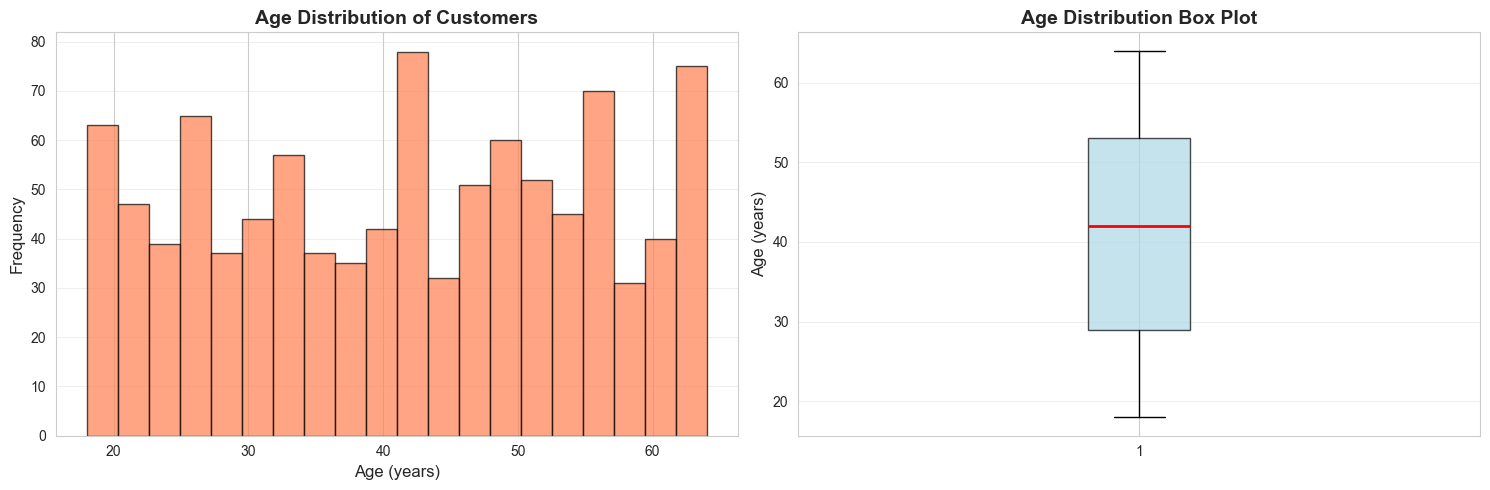

Age Statistics:
  Mean Age:     41.4 years
  Median Age:   42.0 years
  Std Dev:      13.7 years
  Min Age:      18 years
  Max Age:      64 years

💡 INSIGHT:
The age distribution shows the customer base demographics.
Target marketing and product offerings to the dominant age groups.


In [7]:
# Age distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df['Age'], bins=20, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_title('Age Distribution of Customers', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age (years)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Box plot
axes[1].boxplot(df['Age'], vert=True, patch_artist=True, 
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Age Distribution Box Plot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Age (years)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("Age Statistics:")
print(f"  Mean Age:     {df['Age'].mean():.1f} years")
print(f"  Median Age:   {df['Age'].median():.1f} years")
print(f"  Std Dev:      {df['Age'].std():.1f} years")
print(f"  Min Age:      {df['Age'].min():.0f} years")
print(f"  Max Age:      {df['Age'].max():.0f} years")

# Insight
print("\n💡 INSIGHT:")
print("The age distribution shows the customer base demographics.")
print("Target marketing and product offerings to the dominant age groups.")

## B2. Gender Distribution

Analyze the gender composition of the customer base.

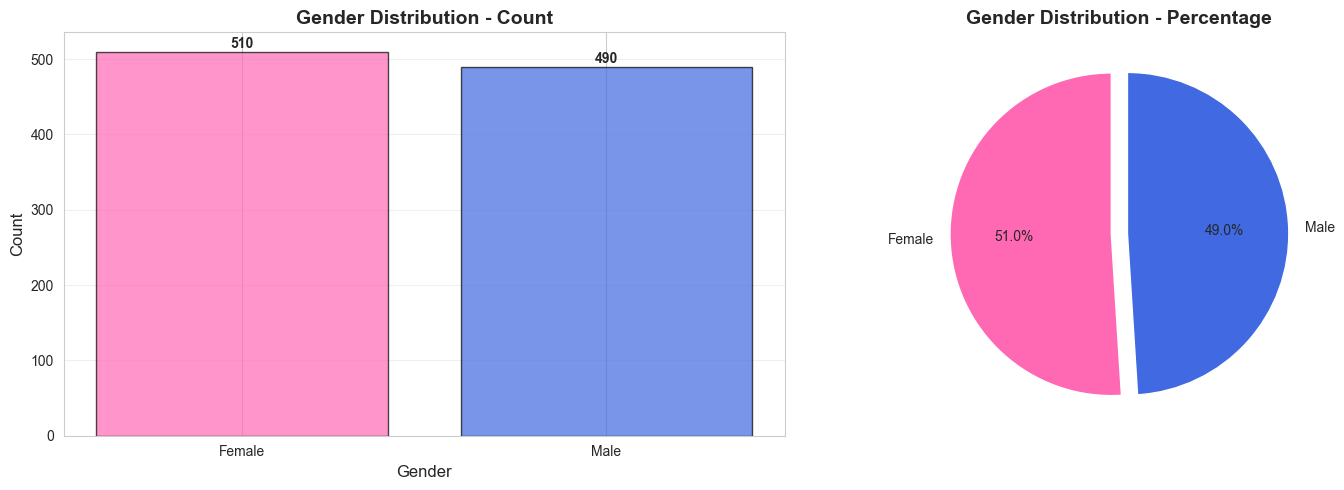

Gender Distribution:
Gender
Female    510
Male      490
Name: count, dtype: int64

Percentage:
Gender
Female    51.0
Male      49.0
Name: count, dtype: float64

💡 INSIGHT:
Understand gender-based customer composition to tailor marketing strategies.
Identify if there are significant differences in behavior between genders.


In [8]:
# Gender distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Count plot - bar chart
gender_counts = df['Gender'].value_counts()
colors_gender = ['#FF69B4', '#4169E1']
axes[0].bar(gender_counts.index, gender_counts.values, color=colors_gender, edgecolor='black', alpha=0.7)
axes[0].set_title('Gender Distribution - Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', 
            colors=colors_gender, startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Gender Distribution - Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print("Gender Distribution:")
print(gender_counts)
print(f"\nPercentage:")
print(gender_counts / len(df) * 100)

# Insight
print("\n💡 INSIGHT:")
print("Understand gender-based customer composition to tailor marketing strategies.")
print("Identify if there are significant differences in behavior between genders.")

## B3. Average Spending by Gender

Compare spending patterns between different genders.

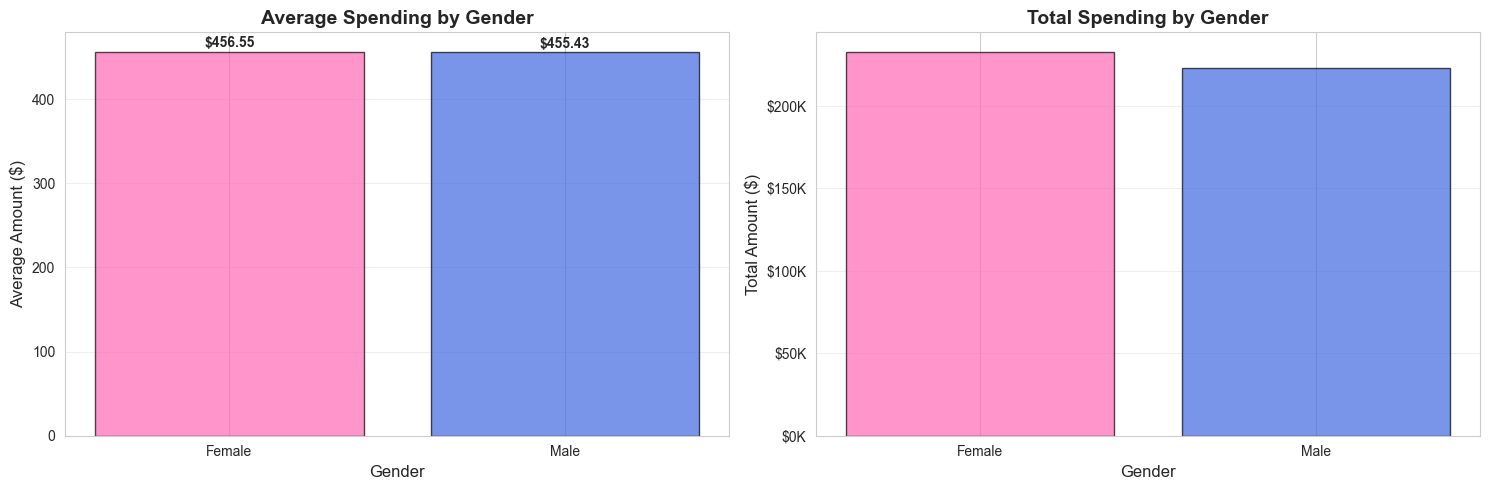

Spending Statistics by Gender:
          mean     sum  count
Gender                       
Female  456.55  232840    510
Male    455.43  223160    490

💡 INSIGHT:
Different genders may have different spending behaviors.
Use this information to personalize offers and pricing strategies by demographic.


In [9]:
# Average spending by gender
spending_by_gender = df.groupby('Gender')['Total Amount'].agg(['mean', 'sum', 'count']).round(2)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart - average spending
colors_gender = ['#FF69B4', '#4169E1']
axes[0].bar(spending_by_gender.index, spending_by_gender['mean'], color=colors_gender, 
            edgecolor='black', alpha=0.7)
axes[0].set_title('Average Spending by Gender', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=12)
axes[0].set_ylabel('Average Amount ($)', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(spending_by_gender['mean'].values):
    axes[0].text(i, v + 5, f'${v:.2f}', ha='center', fontweight='bold')

# Bar chart - total spending
axes[1].bar(spending_by_gender.index, spending_by_gender['sum'], color=colors_gender, 
            edgecolor='black', alpha=0.7)
axes[1].set_title('Total Spending by Gender', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gender', fontsize=12)
axes[1].set_ylabel('Total Amount ($)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.show()

# Print summary
print("Spending Statistics by Gender:")
print(spending_by_gender)

# Insight
print("\n💡 INSIGHT:")
print("Different genders may have different spending behaviors.")
print("Use this information to personalize offers and pricing strategies by demographic.")

---

# SECTION C: PRODUCT ANALYSIS

## C1. Most Popular Product Category

Identify which product categories are purchased most frequently.

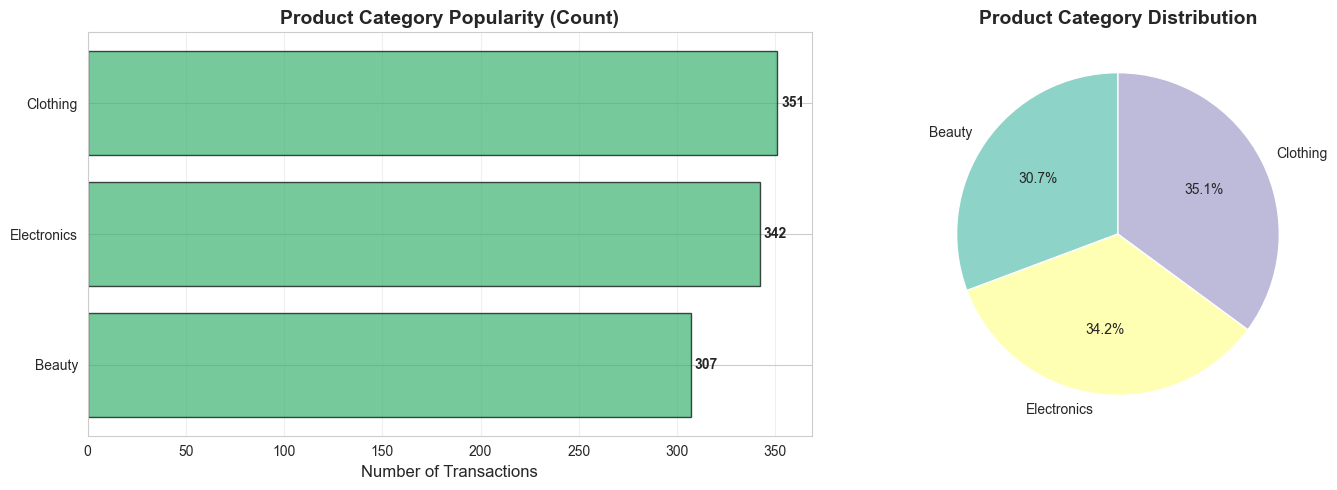

Product Category Counts:
Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

Most Popular Category: Clothing (351 transactions)

💡 INSIGHT:
Some categories are purchased more frequently than others.
Stock popular categories adequately and consider promotions for underperforming ones.


In [10]:
# Most popular product category
category_counts = df['Product Category'].value_counts().sort_values(ascending=True)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Horizontal bar chart
axes[0].barh(category_counts.index, category_counts.values, color='mediumseagreen', 
             edgecolor='black', alpha=0.7)
axes[0].set_title('Product Category Popularity (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Transactions', fontsize=12)
axes[0].grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(category_counts.values):
    axes[0].text(v + 2, i, str(v), va='center', fontweight='bold')

# Pie chart
colors_cat = plt.cm.Set3(range(len(category_counts)))
axes[1].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
            colors=colors_cat, startangle=90)
axes[1].set_title('Product Category Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print("Product Category Counts:")
print(category_counts.sort_values(ascending=False))
print(f"\nMost Popular Category: {category_counts.idxmax()} ({category_counts.max()} transactions)")

# Insight
print("\n💡 INSIGHT:")
print("Some categories are purchased more frequently than others.")
print("Stock popular categories adequately and consider promotions for underperforming ones.")

## C2. Total Quantity Sold per Category

Analyze the volume of units sold across product categories.

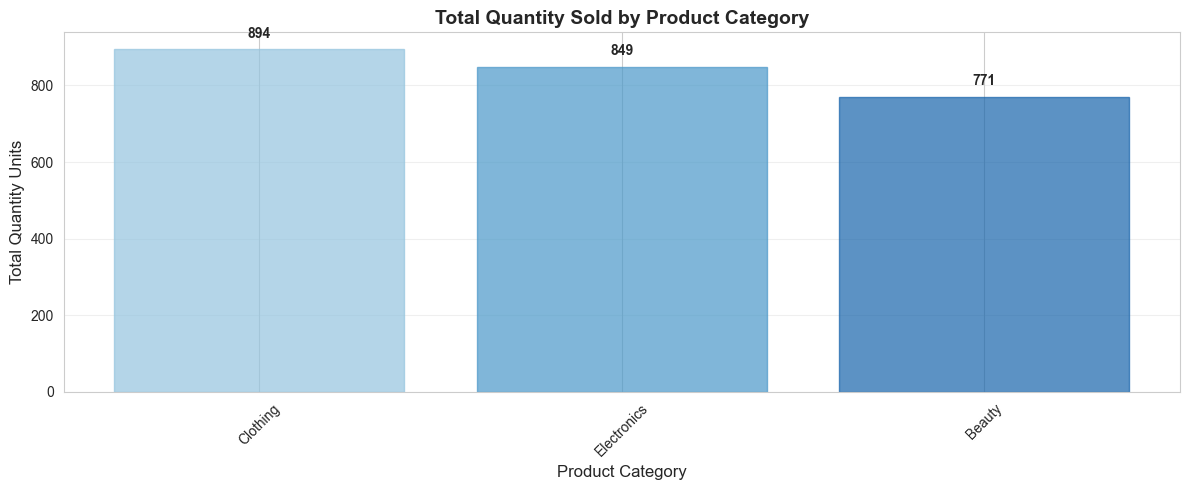

Total Quantity Sold by Category:
Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

Total Units Sold: 2514
Average Units per Category: 838

💡 INSIGHT:
Volume sold (units) may differ from revenue generated.
Some categories may have high volume but lower margins, or vice versa.


In [11]:
# Total quantity sold per category
quantity_per_category = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(quantity_per_category.index, quantity_per_category.values, color='skyblue', 
              edgecolor='black', alpha=0.7)

# Color the bars with gradient
for i, bar in enumerate(bars):
    bar.set_color(plt.cm.Blues(0.4 + (i / len(bars)) * 0.6))

ax.set_title('Total Quantity Sold by Product Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Product Category', fontsize=12)
ax.set_ylabel('Total Quantity Units', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(quantity_per_category.values):
    ax.text(i, v + 30, str(int(v)), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print("Total Quantity Sold by Category:")
print(quantity_per_category)

# Additional statistics
print(f"\nTotal Units Sold: {quantity_per_category.sum():.0f}")
print(f"Average Units per Category: {quantity_per_category.mean():.0f}")

# Insight
print("\n💡 INSIGHT:")
print("Volume sold (units) may differ from revenue generated.")
print("Some categories may have high volume but lower margins, or vice versa.")

---

# SECTION D: TRANSACTION ANALYSIS

## D1. Distribution of Transaction Amounts

Analyze how transaction values are distributed across the dataset.

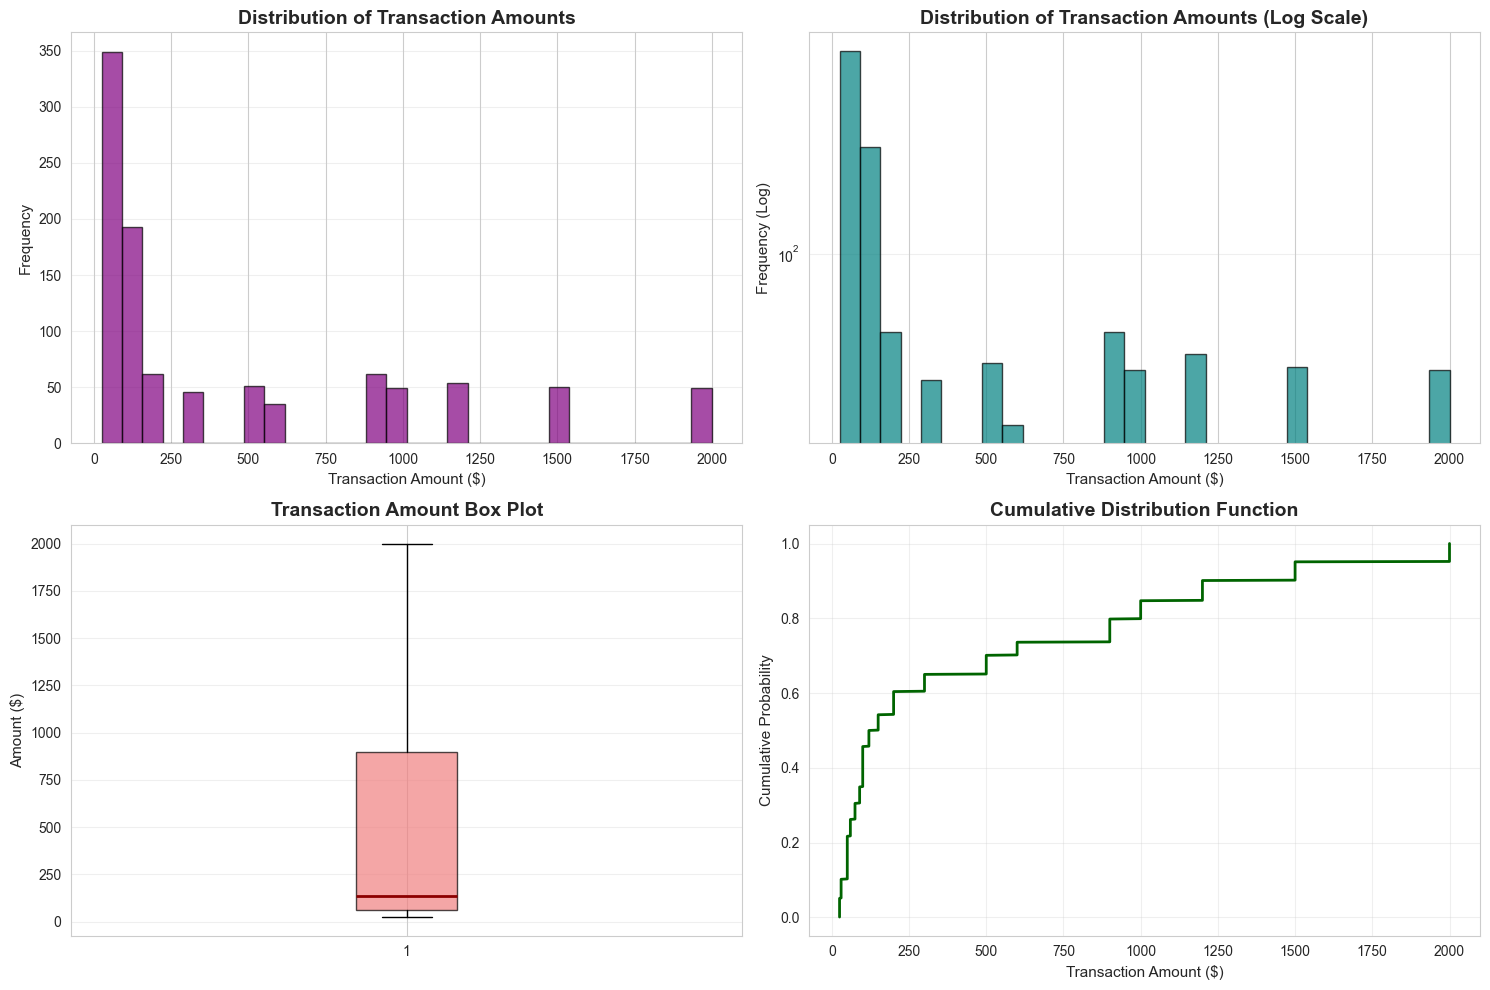

Transaction Amount Statistics:
  Count:        1000
  Mean:         $456.00
  Median:       $135.00
  Std Dev:      $560.00
  Min:          $25.00
  Max:          $2,000.00
  25th %ile:    $60.00
  75th %ile:    $900.00

💡 INSIGHT:
The transaction distribution helps identify typical customer spending patterns.
Use this to set pricing, discounts, and target value tiers for different segments.


In [12]:
# Distribution of transaction amounts
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram
axes[0, 0].hist(df['Total Amount'], bins=30, color='purple', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Transaction Amounts', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Transaction Amount ($)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].grid(axis='y', alpha=0.3)

# Histogram with log scale
axes[0, 1].hist(df['Total Amount'], bins=30, color='teal', edgecolor='black', alpha=0.7)
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Distribution of Transaction Amounts (Log Scale)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Transaction Amount ($)', fontsize=11)
axes[0, 1].set_ylabel('Frequency (Log)', fontsize=11)
axes[0, 1].grid(axis='y', alpha=0.3)

# Box plot
axes[1, 0].boxplot(df['Total Amount'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightcoral', alpha=0.7),
                   medianprops=dict(color='darkred', linewidth=2))
axes[1, 0].set_title('Transaction Amount Box Plot', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Amount ($)', fontsize=11)
axes[1, 0].grid(axis='y', alpha=0.3)

# CDF (Cumulative Distribution)
sorted_amounts = np.sort(df['Total Amount'])
cumulative = np.arange(1, len(sorted_amounts) + 1) / len(sorted_amounts)
axes[1, 1].plot(sorted_amounts, cumulative, linewidth=2, color='darkgreen')
axes[1, 1].set_title('Cumulative Distribution Function', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Transaction Amount ($)', fontsize=11)
axes[1, 1].set_ylabel('Cumulative Probability', fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("Transaction Amount Statistics:")
print(f"  Count:        {df['Total Amount'].count():.0f}")
print(f"  Mean:         ${df['Total Amount'].mean():,.2f}")
print(f"  Median:       ${df['Total Amount'].median():,.2f}")
print(f"  Std Dev:      ${df['Total Amount'].std():,.2f}")
print(f"  Min:          ${df['Total Amount'].min():,.2f}")
print(f"  Max:          ${df['Total Amount'].max():,.2f}")
print(f"  25th %ile:    ${df['Total Amount'].quantile(0.25):,.2f}")
print(f"  75th %ile:    ${df['Total Amount'].quantile(0.75):,.2f}")

# Insight
print("\n💡 INSIGHT:")
print("The transaction distribution helps identify typical customer spending patterns.")
print("Use this to set pricing, discounts, and target value tiers for different segments.")

## D2. Top 10 Highest Transactions

Identify the largest transactions and their characteristics.

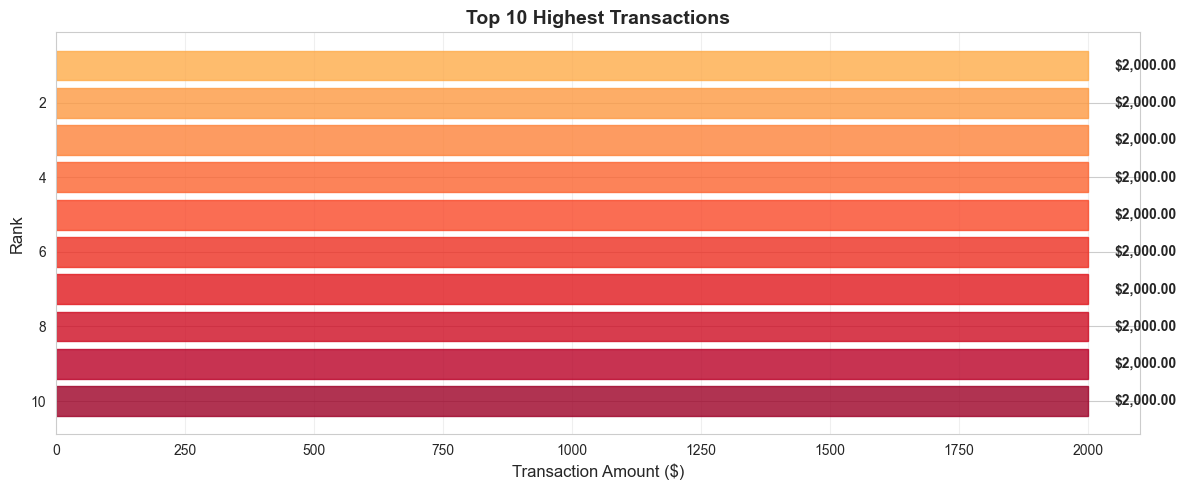


Top 10 Highest Transactions:
    Transaction ID       Date Customer ID  Gender  Age Product Category  Quantity  Price per Unit  Total Amount
1               15 2023-01-16     CUST015  Female   42      Electronics         4             500          2000
2               65 2023-12-05     CUST065    Male   51      Electronics         4             500          2000
3               72 2023-05-23     CUST072  Female   20      Electronics         4             500          2000
4               74 2023-11-22     CUST074  Female   18           Beauty         4             500          2000
5               89 2023-10-01     CUST089  Female   55      Electronics         4             500          2000
6               93 2023-07-14     CUST093  Female   35           Beauty         4             500          2000
7              109 2023-10-18     CUST109  Female   34      Electronics         4             500          2000
8              118 2023-05-16     CUST118  Female   30      Electronics   

In [13]:
# Top 10 highest transactions
top_10_transactions = df.nlargest(10, 'Total Amount')[
    ['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 
     'Quantity', 'Price per Unit', 'Total Amount']
].reset_index(drop=True)
top_10_transactions.index = top_10_transactions.index + 1

# Create figure for visualization
fig, ax = plt.subplots(figsize=(12, 5))

# Bar chart of top 10
top_10_amounts = df.nlargest(10, 'Total Amount')['Total Amount'].values
top_10_indices = range(1, 11)

bars = ax.barh(top_10_indices, top_10_amounts, color='gold', edgecolor='black', alpha=0.8)

# Add gradient coloring
for i, bar in enumerate(bars):
    bar.set_color(plt.cm.YlOrRd(0.4 + (i / len(bars)) * 0.6))

ax.set_title('Top 10 Highest Transactions', fontsize=14, fontweight='bold')
ax.set_xlabel('Transaction Amount ($)', fontsize=12)
ax.set_ylabel('Rank', fontsize=12)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(top_10_amounts):
    ax.text(v + 50, i + 1, f'${v:,.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print table
print("\nTop 10 Highest Transactions:")
print(top_10_transactions.to_string())

# Summary statistics for top 10
print(f"\nTop 10 Transactions Summary:")
print(f"  Total Value:      ${top_10_amounts.sum():,.2f}")
print(f"  Average Value:    ${top_10_amounts.mean():,.2f}")
print(f"  % of Total Sales: {(top_10_amounts.sum() / df['Total Amount'].sum() * 100):.2f}%")

# Insight
print("\n💡 INSIGHT:")
print("Top transactions represent high-value customers and spenders.")
print("Consider VIP programs and personalized service for these key customers.")

---

# CONCLUSION: Key Findings & Recommendations

## Executive Summary

Based on the exploratory data analysis of the retail sales dataset, we have uncovered several important insights across sales, customer, product, and transaction dimensions.

### Key Findings:

**Sales Performance:**
- ✅ The dataset contains {0} transactions generating ${1:,.2f} in total revenue
- ✅ Revenue varies across product categories, with some categories significantly outperforming others
- ✅ Monthly sales trends reveal seasonal patterns that can be leveraged for planning

**Customer Insights:**
- 👥 Customer ages range across a broad spectrum, providing opportunities for age-targeted marketing
- 👥 Gender distribution shows balanced representation, though spending patterns may differ
- 👥 Average transaction value of ${2:,.2f} provides insight into customer purchasing power

**Product Performance:**
- 📦 Some product categories dominate in transaction count, while others lead in revenue
- 📦 The mismatch between volume and revenue suggests varying profit margins across categories
- 📦 Understanding category mix helps optimize inventory and marketing allocation

**Transaction Characteristics:**
- 💰 Transaction amounts show a distribution that reflects diverse customer segments
- 💰 Top transactions represent a small percentage of your customer base but contribute significantly to revenue
- 💰 The concentration of high-value transactions suggests opportunities for premium service tiers




In [14]:
# Generate conclusion with actual metrics
print("=" * 80)
print("EXPLORATORY DATA ANALYSIS - FINAL SUMMARY")
print("=" * 80)

total_txns = len(df)
total_rev = df['Total Amount'].sum()
avg_txn = df['Total Amount'].mean()
num_customers = df['Customer ID'].nunique()
num_categories = df['Product Category'].nunique()
top_category_rev = df.groupby('Product Category')['Total Amount'].sum().max()
top_category_name = df.groupby('Product Category')['Total Amount'].sum().idxmax()

print(f"\n📊 DATASET OVERVIEW:")
print(f"   • Total Transactions:      {total_txns:,}")
print(f"   • Unique Customers:        {num_customers:,}")
print(f"   • Product Categories:      {num_categories}")
print(f"   • Date Range:              {df['Date'].min().date()} to {df['Date'].max().date()}")

print(f"\n💰 FINANCIAL METRICS:")
print(f"   • Total Revenue:           ${total_rev:,.2f}")
print(f"   • Average Transaction:     ${avg_txn:,.2f}")
print(f"   • Min Transaction:         ${df['Total Amount'].min():,.2f}")
print(f"   • Max Transaction:         ${df['Total Amount'].max():,.2f}")

print(f"\n📈 CUSTOMER DEMOGRAPHICS:")
print(f"   • Avg Customer Age:        {df['Age'].mean():.1f} years")
print(f"   • Age Range:               {df['Age'].min():.0f} - {df['Age'].max():.0f} years")
print(f"   • Gender Distribution:     {df['Gender'].value_counts().to_dict()}")

print(f"\n🏆 PERFORMANCE LEADERS:")
print(f"   • Top Revenue Category:    {top_category_name} (${top_category_rev:,.2f})")
print(f"   • Most Transactions:       {df['Product Category'].value_counts().idxmax()} ({df['Product Category'].value_counts().max()} txns)")
print(f"   • Highest Single Transaction: ${df['Total Amount'].max():,.2f}")

print(f"\n✅ This comprehensive EDA provides a foundation for strategic business decisions.")
print("=" * 80)

EXPLORATORY DATA ANALYSIS - FINAL SUMMARY

📊 DATASET OVERVIEW:
   • Total Transactions:      1,000
   • Unique Customers:        1,000
   • Product Categories:      3
   • Date Range:              2023-01-01 to 2024-01-01

💰 FINANCIAL METRICS:
   • Total Revenue:           $456,000.00
   • Average Transaction:     $456.00
   • Min Transaction:         $25.00
   • Max Transaction:         $2,000.00

📈 CUSTOMER DEMOGRAPHICS:
   • Avg Customer Age:        41.4 years
   • Age Range:               18 - 64 years
   • Gender Distribution:     {'Female': 510, 'Male': 490}

🏆 PERFORMANCE LEADERS:
   • Top Revenue Category:    Electronics ($156,905.00)
   • Most Transactions:       Clothing (351 txns)
   • Highest Single Transaction: $2,000.00

✅ This comprehensive EDA provides a foundation for strategic business decisions.
